In [2]:
import sys, os
sys.path.append(os.path.abspath('../'))
from tqdm import tqdm
from methods.simulations.simulation_new import generate_simulation , treatment_probability
from methods.classic_baselines.src.utils import compute_treatment_effects, monte_carlo_ATE,estimate_ATE, run_methods
from methods.classic_baselines.src.methods import did, ols, synthetic_control, elastic_net, synthetic_did, synthetic_control_with_dtw
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
simulation_params = {
        "n_units": 10000,
        "n_time": 84 * 2,
        "treatment_time": 84,
        "phi": 0.8,
        "sigma": 5,
        "alpha": 0.05,
        "seed": None,
        "bias": True,
        "constant_effect": True,
    }

In [4]:
simulation_params['seed'] = 42
df = generate_simulation(**simulation_params)

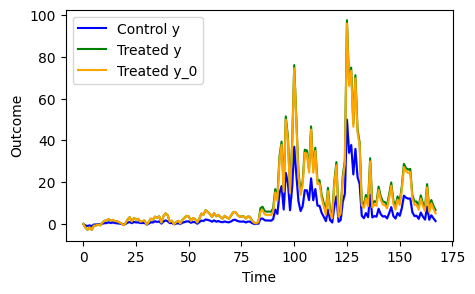

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm



# Separate treated and control groups
treated = df[df['treatment'] == 1]
control = df[df['treatment'] == 0]

# Function to compute mean and confidence intervals for a group
def compute_group_statistics(group, value_col, time_col):
    stats = group.groupby(time_col)[value_col].agg(['mean', 'count', 'std']).reset_index()
    stats['se'] = stats['std'] / np.sqrt(stats['count'])  # Standard Error
    z = norm.ppf(0.975)  # z-value for 95% confidence
    stats['ci_lower'] = stats['mean'] - z * stats['se']
    stats['ci_upper'] = stats['mean'] + z * stats['se']
    return stats

# Compute statistics for control, treated y_1, and treated y_0
control_stats = compute_group_statistics(control, 'y_0', 'time')
treated_y1_stats = compute_group_statistics(treated, 'y', 'time')
treated_y0_stats = compute_group_statistics(treated, 'y_0', 'time')

# Plotting
plt.figure(figsize=(5, 3))

# Plot control group
plt.plot(control_stats['time'], control_stats['mean'], label='Control y', color='blue')
plt.fill_between(control_stats['time'], control_stats['ci_lower'], control_stats['ci_upper'], 
                 color='blue', alpha=0.2)

# Plot treated y_1
plt.plot(treated_y1_stats['time'], treated_y1_stats['mean'], label='Treated y', color='green')
# plt.fill_between(treated_y1_stats['time'], treated_y1_stats['ci_lower'], treated_y1_stats['ci_upper'], 
#                  color='green', alpha=0.2)

# Plot treated y_0
plt.plot(treated_y0_stats['time'], treated_y0_stats['mean'], label='Treated y_0', color='orange')
plt.fill_between(treated_y0_stats['time'], treated_y0_stats['ci_lower'], treated_y0_stats['ci_upper'], 
                 color='orange', alpha=0.2)

# Highlight overlapping regions on y_0
overlap_lower = np.maximum(control_stats['ci_lower'], treated_y0_stats['ci_lower'])
overlap_upper = np.minimum(control_stats['ci_upper'], treated_y0_stats['ci_upper'])
# plt.fill_between(control_stats['time'], overlap_lower, overlap_upper, 
                #  where=(overlap_lower < overlap_upper), color='purple', alpha=0.3, label='Overlap Region')

# Add labels, legend, and show plot
plt.xlabel('Time')
plt.ylabel('Outcome')
plt.legend()
# plt.title('Mean Outcomes with 95% Confidence Intervals and Overlap')
plt.show()


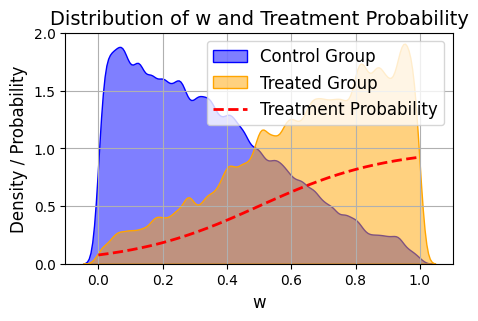

In [11]:
# Separate treated and control groups
treated_group = df[df['treatment'] == 1]
control_group = df[df['treatment'] == 0]

# Plot probability distributions
plt.figure(figsize=(5, 3))
sns.kdeplot(control_group['w'], label='Control Group', color='blue', fill=True, alpha=0.5)
sns.kdeplot(treated_group['w'], label='Treated Group', color='orange', fill=True, alpha=0.5)
w_t_range = np.linspace(df['w'].min(), df['w'].max(), 500)
treatment_prob = treatment_probability(w_t_range).astype(float)  # Based on the treatment_probability function
plt.plot(w_t_range, treatment_prob, label='Treatment Probability', color='red', linestyle='--', linewidth=2)

# Customize plot
plt.title('Distribution of w and Treatment Probability', fontsize=14)
plt.xlabel('w', fontsize=12)
plt.ylabel('Density / Probability', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [12]:
real_ate =np.mean(monte_carlo_ATE(simulation_params,n_iter=10))
print( real_ate)

1.5400000000000007


In [8]:
# methods  = [did,ols,synthetic_control,elastic_net,elastic_net,elastic_net,synthetic_did, synthetic_control_with_dtw]
methods  = [ols]

methods_name=["did","ols",'synthetic_control',"lasso","ridge","elastic_net","synthetic_did","synthetic_dtw"]
did_params = {'id_col':'id', 'index_col': 'time','treat_col':'treatment','outcome_col':'y', 'intervention_point':simulation_params['treatment_time'],  'ratio':None}
ols_params = {'id_col':'id', 'index_col': 'time','treat_col':'treatment','outcome_col':'y', 'intervention_point':simulation_params['treatment_time'],  'ratio':None}
synthetic_control_params = {'id_col':'id', 'index_col': 'time','treat_col':'treatment','outcome_col':'y', 'intervention_point':simulation_params['treatment_time'],  'ratio':None}
lasso_params = {'id_col':'id', 'index_col': 'time','treat_col':'treatment','outcome_col':'y', 'intervention_point':simulation_params['treatment_time'],  'ratio':1}
ridge_params = {'id_col':'id', 'index_col': 'time','treat_col':'treatment','outcome_col':'y', 'intervention_point':simulation_params['treatment_time'],  'ratio':0}
elastic_net_params = {'id_col':'id', 'index_col': 'time','treat_col':'treatment','outcome_col':'y', 'intervention_point':simulation_params['treatment_time'],  'ratio':0.5}
synthetic_did_params = {'id_col':'id', 'index_col': 'time','treat_col':'treatment','outcome_col':'y', 'intervention_point':simulation_params['treatment_time'],  'ratio':None}
synthetic_control_with_dtw_params = {'id_col':'id', 'index_col': 'time','treat_col':'treatment','outcome_col':'y', 'intervention_point':simulation_params['treatment_time'],  'ratio':None}
# func_params = [did_params,ols_params,synthetic_control_params,lasso_params,ridge_params,elastic_net_params,synthetic_did_params, synthetic_control_with_dtw_params]
func_params = [ols_params]

test = run_methods(df, methods, func_params)
test[0]

[11.004982011272759]

In [1]:
## plots 
import pickle 
import numpy as np 
with open('../results/att_classic_bias=True_constant_effect=True_sigma=5_alpha=0.05.pkl', 'rb') as f:
    output = pickle.load(f)
    
with open('../results/B-Twin_att_results_bias=True_constant_effect=True_sigma=5_alpha=0.05.pkl', 'rb') as f:
    att_B_twin = pickle.load(f)
    
    
with open('../results/B-Twin_C1_att_results_bias=True_constant_effect=True_sigma=5_alpha=0.05.pkl', 'rb') as f:
    att_B_twin_C1 = pickle.load(f)

with open('../results/B-Twin_C2_att_results_bias=True_constant_effect=True_sigma=5_alpha=0.05.pkl', 'rb') as f:
    att_B_twin_C2 = pickle.load(f)
    
with open('../results/B-Twin_O_att_results_bias=True_constant_effect=True_sigma=5_alpha=0.05.pkl', 'rb') as f:
    att_B_twin_O = pickle.load(f)
    
with open('../results/att_synctwin_with_bias=True_constant_effect=True_sigma=5_alpha=0.05.pkl', 'rb') as f:
    att_Synctwin = pickle.load(f)
    
with open('../results/nn_baselines_new/simulated_data_(sim_3)_experiment_ts_att_bias=True_const=True_sigma=5_alpha=0.05.pkl','rb') as f :
    results_nn_baselines = pickle.load(f)

In [125]:
# att_classic_baseliens = output[:100,0,:]
# att_B_twin = list(att_B_twin)[:100]
# att_B_twin_C1 = list(att_B_twin_C1)[:100]
# att_B_twin_C2 = list(att_B_twin_C2)[:100]
# att_B_twin_O = list(att_B_twin_O)[:100]
# att_Synctwin=att_Synctwin[:100]
att_classic_baseliens = output[:,0,:]
att_B_twin = list(att_B_twin)
att_B_twin_C1 = list(att_B_twin_C1)
att_B_twin_C2 = list(att_B_twin_C2)
att_B_twin_O = list(att_B_twin_O)
att_Synctwin=att_Synctwin


for i in range(len(att_B_twin)):
    att_B_twin[i] = att_B_twin[i].cpu().detach().numpy()
    

for i in range(len(att_B_twin_C1)):
    att_B_twin_C1[i] = att_B_twin_C1[i].cpu().detach().numpy()
    

for i in range(len(att_B_twin_C2)):
    att_B_twin_C2[i] = att_B_twin_C2[i].cpu().detach().numpy()

for i in range(len(att_B_twin_O)):
    att_B_twin_O[i] = att_B_twin_O[i].cpu().detach().numpy()



In [126]:
att_B_twin_mean = []
for i in (range(len(att_B_twin))):
    att_B_twin_mean.append(np.mean(att_B_twin[i]))
    
att_B_twin_C1_mean = []
for i in (range(len(att_B_twin_C1))):
    att_B_twin_C1_mean.append(np.mean(att_B_twin_C1[i]))
    
att_B_twin_C2_mean = []
for i in (range(len(att_B_twin_C2))):
    att_B_twin_C2_mean.append(np.mean(att_B_twin_C2[i]))
att_B_twin_O_mean = []
for i in (range(len(att_B_twin_O))):
    att_B_twin_O_mean.append(np.mean(att_B_twin_O[i]))
ate_nn_baselines = np.array(results_nn_baselines)[:,:,1] 


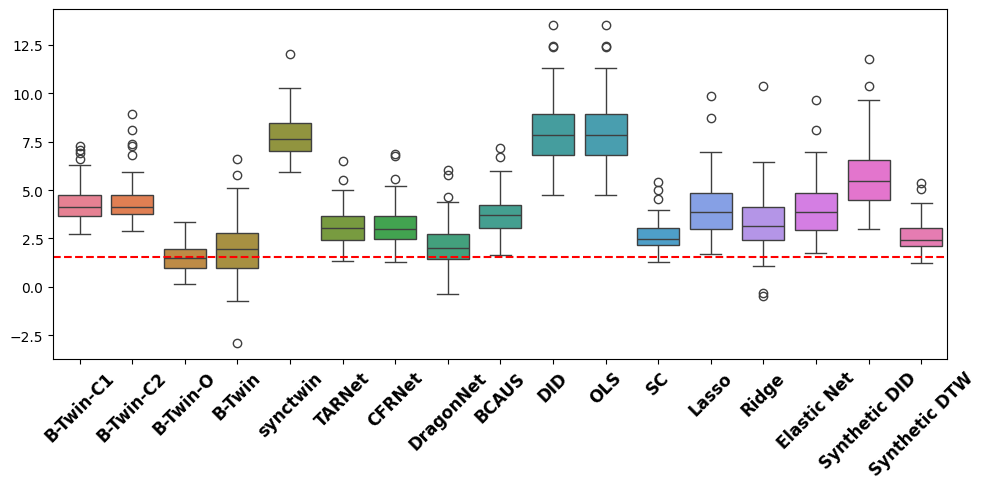

In [127]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Combine all methods' data into a DataFrame
methods_name = ["B-Twin-C1","B-Twin-C2","B-Twin-O" ,"B-Twin" ,"synctwin","TARNet", "CFRNet", "DragonNet", "BCAUS","DID", "OLS", "SC", "Lasso", "Ridge", "Elastic Net", "Synthetic DID", "Synthetic DTW"]
# methods_name = ["B-Twin-C1","B-Twin-C2","B-Twin-O" ,"B-Twin" ,"synctwin","DID", "OLS", "SC", "Lasso", "Ridge", "Elastic Net", "Synthetic DID", "Synthetic DTW"]

methods_data = {
                methods_name[0]:att_B_twin_C1_mean,methods_name[1]:att_B_twin_C2_mean,
                methods_name[2]:att_B_twin_O_mean,methods_name[3]:att_B_twin_mean,
               methods_name[4]:att_Synctwin,
               methods_name[5]:ate_nn_baselines[:,0],methods_name[6]:ate_nn_baselines[:,1],
               methods_name[7]:ate_nn_baselines[:,2],methods_name[8]:ate_nn_baselines[:,3],
    **{methods_name[i+9]: att_classic_baseliens[:, i] for i in range(att_classic_baseliens.shape[1])}
}
# methods_data = {
#                 methods_name[0]:att_B_twin_C1_mean,methods_name[1]:att_B_twin_C2_mean,
#                 methods_name[2]:att_B_twin_O_mean,methods_name[3]:att_B_twin_mean,
#                 methods_name[4]:att_Synctwin,

#     **{methods_name[i+5]: att_classic_baseliens[:, i] for i in range(att_classic_baseliens.shape[1])}
# }
df = pd.DataFrame(methods_data)

# Create the boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df)
plt.xticks(rotation=45,fontsize=12,fontweight='bold')  # Rotate method names if needed

# Add real ATE line
real_ate = 0.77*2
plt.axhline(real_ate, color='red', linestyle='--', label='Real Value')

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

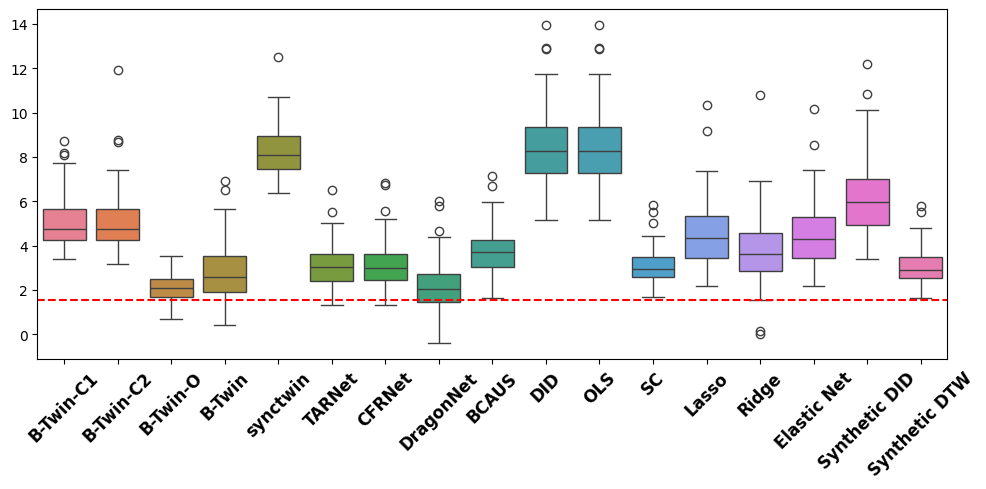

In [101]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Combine all methods' data into a DataFrame
methods_name = ["B-Twin-C1","B-Twin-C2","B-Twin-O" ,"B-Twin" ,"synctwin","TARNet", "CFRNet", "DragonNet", "BCAUS","DID", "OLS", "SC", "Lasso", "Ridge", "Elastic Net", "Synthetic DID", "Synthetic DTW"]
# methods_name = ["B-Twin-C1","B-Twin-C2","B-Twin-O" ,"B-Twin" ,"synctwin","DID", "OLS", "SC", "Lasso", "Ridge", "Elastic Net", "Synthetic DID", "Synthetic DTW"]

methods_data = {
                methods_name[0]:att_B_twin_C1_mean,methods_name[1]:att_B_twin_C2_mean,
                methods_name[2]:att_B_twin_O_mean,methods_name[3]:att_B_twin_mean,
               methods_name[4]:att_Synctwin,
               methods_name[5]:ate_nn_baselines[:,0],methods_name[6]:ate_nn_baselines[:,1],
               methods_name[7]:ate_nn_baselines[:,2],methods_name[8]:ate_nn_baselines[:,3],
    **{methods_name[i+9]: att_classic_baseliens[:, i] for i in range(att_classic_baseliens.shape[1])}
}
# methods_data = {
#                 methods_name[0]:att_B_twin_C1_mean,methods_name[1]:att_B_twin_C2_mean,
#                 methods_name[2]:att_B_twin_O_mean,methods_name[3]:att_B_twin_mean,
#                 methods_name[4]:att_Synctwin,

#     **{methods_name[i+5]: att_classic_baseliens[:, i] for i in range(att_classic_baseliens.shape[1])}
# }
df = pd.DataFrame(methods_data)

# Create the boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df)
plt.xticks(rotation=45,fontsize=12,fontweight='bold')  # Rotate method names if needed

# Add real ATE line
real_ate = 0.77*2
plt.axhline(real_ate, color='red', linestyle='--', label='Real Value')

plt.tight_layout()  # Adjust layout for better spacing
plt.show()